<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# СӨЖ
# Сверткалық Нейрондық Желілер (CNN) және CIFAR-10

**Мақсаты:** Сверткалық нейрондық желілердің (CNN) жұмыс істеу принципін түсіну және CIFAR-10 деректер жиынтығындағы түрлі-түсті суреттерді классификациялау үшін модель құру.

**Сіздің тапсырмаңыз:** Төмендегі код ұяшықтарында `# TODO` деп белгіленген жерлерді дұрыс кодпен немесе мәнмен толтыру.




### 1. Қысқаша теория

Сверткалық нейрондық желілер (CNN) – бұл суреттерді өңдеуге арналған ең тиімді архитектура. Ол негізгі үш бөліктен тұрады:

1. **Convolutional Layer (Сверткалық қабат):** Суреттің үстінен кішкентай "сүзгілер" (filters) жүргізу арқылы маңызды белгілерді (сызықтар, бұрыштар, фактуралар) бөліп алады.
* *Функция:* `layers.Conv2D`


2. **Pooling Layer (Пулинг қабаты):** Суреттің өлшемін кішірейтеді, есептеуді жеңілдетеді және маңызды ақпаратты қалдырады. Ең көп тарағаны – Max Pooling (аймақтағы ең үлкен мәнді алу).
* *Функция:* `layers.MaxPooling2D`


3. **Fully Connected Layer (Толық байланысқан қабат):** Соңында табылған белгілерді біріктіріп, суреттің қай класқа жататынын анықтайды.
* *Функция:* `layers.Dense`



Алдымен қажетті кітапханаларды қосайық.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Нұсқаны тексеру
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0



### 2. Деректерді жүктеу (CIFAR-10)

Біз **CIFAR-10** датасетін қолданамыз. Онда 10 түрлі класқа жататын 60,000 түрлі-түсті сурет (32x32 пиксель) бар.
Кластар: *'ұшақ', 'автокөлік', 'құс', 'мысық', 'бұғы', 'ит', 'бақа', 'жылқы', 'кеме', 'жүк көлігі'.*


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


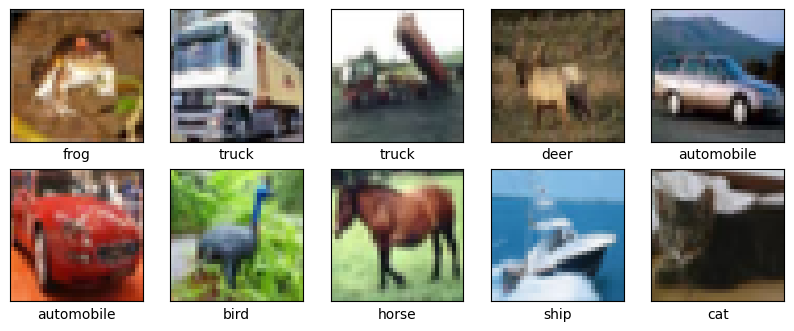

In [2]:
# Деректерді жүктеу
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Пиксель мәндерін 0 мен 1 аралығына келтіру (Нормализация)
# TODO: Студент сурет пиксельдерін нормализациялауы керек (255.0-ге бөлу)
# Пиксель мәндерін 0 мен 1 аралығына келтіру
train_images = train_images / 255.0
test_images = test_images / 255.0

# Класс атаулары
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Деректердің дұрыс жүктелгенін тексеру (алғашқы 10 суретті шығару)
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # CIFAR labels массивтер массиві болып табылады, сондықтан қосымша индекс керек
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()


### 3. CNN Архитектурасын құру (Негізгі тапсырма)

Бұл бөлімде сіз нейрондық желінің "қаңқасын" жинайсыз.
Сызба мынадай болуы керек:

1. **Conv2D:** 32 фильтр, (3, 3) өлшем, 'relu' активациясы, кіріс өлшемі (32, 32, 3).
2. **MaxPooling2D:** (2, 2) өлшемі.
3. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
4. **MaxPooling2D:** (2, 2) өлшемі.
5. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
6. **Flatten:** Векторға айналдыру.
7. **Dense:** 64 нейрон, 'relu' активациясы.
8. **Dense (Шығыс):** 10 нейрон (кластар саны).

**Тапсырма:** Төмендегі кодта қалдырылған `# TODO` орындарын толтырыңыз.


In [3]:
model = models.Sequential()

# 1-қабат: Convolution
model.add(
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    )
)

# 2-қабат: MaxPooling
model.add(
    layers.MaxPooling2D((2, 2))
)

# 3-қабат
model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

# 4-қабат
model.add(
    layers.MaxPooling2D((2, 2))
)

# 5-қабат
model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

# Flatten
model.add(layers.Flatten())

# Dense
model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

# Шығыс қабаты
model.add(
    layers.Dense(10)
)

# Тексеру
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


### 4. Модельді компиляциялау және оқыту

Модель дайын, енді оны оқыту ережелерін бекітуіміз керек.

* **Optimizer:** `adam` (ең танымал оптимизатор).
* **Loss Function:** `SparseCategoricalCrossentropy` (кластар сандармен берілген кезде қолданылады).
* **Metrics:** `accuracy` (дәлдік).

**Тапсырма:** Компиляция және оқыту параметрлерін толтырыңыз.


In [4]:
# Компиляция
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Оқыту
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.4568 - loss: 1.4967 - val_accuracy: 0.5755 - val_loss: 1.1901
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6008 - loss: 1.1247 - val_accuracy: 0.6188 - val_loss: 1.0858
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6572 - loss: 0.9780 - val_accuracy: 0.6695 - val_loss: 0.9498
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6917 - loss: 0.8823 - val_accuracy: 0.6856 - val_loss: 0.9070
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7151 - loss: 0.8168 - val_accuracy: 0.6890 - val_loss: 0.8914
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7354 - loss: 0.7553 - val_accuracy: 0.6943 - val_loss: 0.8813
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7526 - loss: 0.7058 - val_accuracy: 0.7077 - val_loss: 0.8540
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7654 - loss: 0.6650 -

In [5]:
better_model = models.Sequential()

# Block 1
better_model.add(
    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    )
)

better_model.add(
    layers.BatchNormalization()
)

better_model.add(
    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    )
)

better_model.add(
    layers.MaxPooling2D((2,2))
)

better_model.add(
    layers.Dropout(0.25)
)

# Block 2
better_model.add(
    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    )
)

better_model.add(
    layers.BatchNormalization()
)

better_model.add(
    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    )
)

better_model.add(
    layers.MaxPooling2D((2,2))
)

better_model.add(
    layers.Dropout(0.25)
)

# Block 3
better_model.add(
    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    )
)

better_model.add(
    layers.BatchNormalization()
)

better_model.add(
    layers.MaxPooling2D((2,2))
)

better_model.add(
    layers.Dropout(0.25)
)

# Classification
better_model.add(layers.Flatten())

better_model.add(
    layers.Dense(
        256,
        activation='relu'
    )
)

better_model.add(
    layers.Dropout(0.5)
)

better_model.add(layers.Dense(10))

# Compile
better_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

better_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
history = better_model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.3719 - loss: 1.7376 - val_accuracy: 0.4905 - val_loss: 1.4803
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5359 - loss: 1.2992 - val_accuracy: 0.6097 - val_loss: 1.1377
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6127 - loss: 1.1071 - val_accuracy: 0.6926 - val_loss: 0.8908
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6588 - loss: 0.9868 - val_accuracy: 0.6825 - val_loss: 0.9147
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6932 - loss: 0.9009 - val_accuracy: 0.7021 - val_loss: 0.9083
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7099 - loss: 0.8417 - val_accuracy: 0.6960 - val_loss: 0.8943
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7269 - loss: 0.7937 - val_accuracy: 0.7409 - val_loss: 0.7707
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7476 - loss: 0.7367 - val_accuracy: 



### 5. Нәтижелерді бағалау

Модельдің оқу барысында қателіктер қалай азайғанын және дәлдік қалай өскенін график арқылы көрейік.


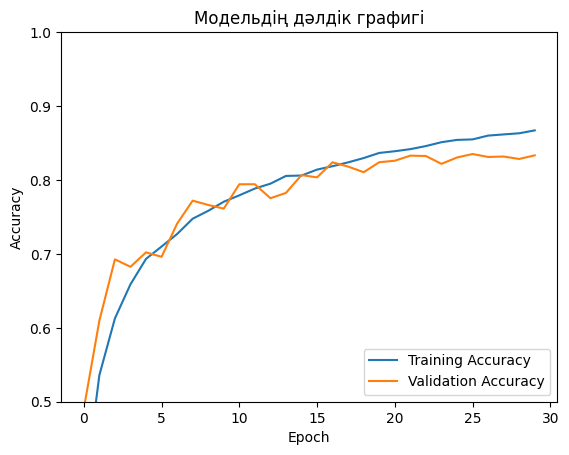

313/313 - 2s - 7ms/step - accuracy: 0.8333 - loss: 0.5524

Модельдің тесттегі дәлдігі: 83.33%


In [7]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Модельдің дәлдік графигі')
plt.show()

test_loss, test_acc = better_model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print(f"\nМодельдің тесттегі дәлдігі: {test_acc*100:.2f}%")


### 6. Модельді тексеру (Prediction)

Енді моделіміз нақты суретті қалай танитынын тексерейік. Біз тест жиынтығынан кездейсоқ бір суретті алып, модельге ұсынамыз.


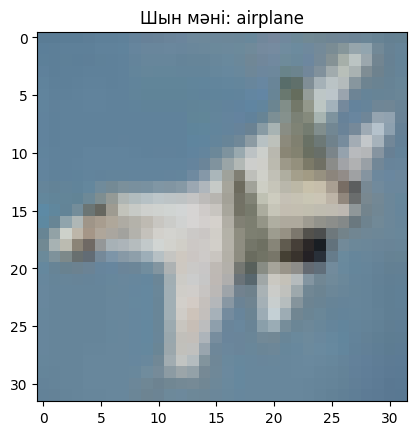

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
Бұл сурет 58.67% ықтималдықпен 'airplane' деп танылды.


In [8]:
# Тест жиынтығынан 10-шы суретті алайық
n = 10

plt.imshow(test_images[n])
plt.title(f"Шын мәні: {class_names[test_labels[n][0]]}")
plt.show()

# Болжам жасау
# Суретті (32,32,3) пішінінен (1, 32, 32, 3) пішініне ауыстыру керек (batch өлшемі)
img_array = np.expand_dims(test_images[n], axis=0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(f"Бұл сурет {100 * np.max(score):.2f}% ықтималдықпен '{class_names[np.argmax(score)]}' деп танылды.")



### Қорытынды сұрақтар

Зертханалық жұмысты қорғау үшін келесі сұрақтарға жауап дайындаңыз:

1. Неліктен Conv2D қолданамыз?

Conv2D суреттегі:

шекаралар,
текстуралар,
бұрыштар,
объект белгілерін

автоматты түрде анықтайды.

Ал жай Dense қабаттары:

пиксельдердің кеңістіктік құрылымын сақтамайды,
параметр саны өте көп болады,
суреттермен нашар жұмыс істейді.
2. MaxPooling не үшін қажет?

MaxPooling:

сурет өлшемін кішірейтеді,
есептеуді азайтады,
маңызды белгілерді сақтайды,
overfitting-ті азайтады.

Мысалы:

32×32→16×16
3. Epoch санын 50-ге өсірсек не болады?

Басында accuracy өседі.
Бірақ кейін модель train деректерін жаттап алуы мүмкін.

Бұл құбылыс:

Overfitting

деп аталады.

Сонда:

train accuracy өте жоғары,
validation accuracy төмендей бастайды.

Оны азайту үшін:

Dropout
Data Augmentation
Early Stopping
Regularization

қолданылады.

# Жалпы дәлдік 90+